### Requried Libraries

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

RANDOM_STATE = 42

### Import Dataset

In [35]:
df = pd.read_csv("housing.csv")
df.rename(columns = {"median_house_value": "Price"}, inplace=True)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,Price,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Clean the Data

In [36]:
df = df.dropna()
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)
df.shape

(20433, 13)

In [37]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,Price,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


### Check Correlations

In [38]:
corr = df.corr(numeric_only=True)["Price"].sort_values(ascending=False)
corr

Price                         1.000000
median_income                 0.688355
ocean_proximity_NEAR BAY      0.160526
ocean_proximity_NEAR OCEAN    0.140378
total_rooms                   0.133294
housing_median_age            0.106432
households                    0.064894
total_bedrooms                0.049686
ocean_proximity_ISLAND        0.023525
population                   -0.025300
longitude                    -0.045398
latitude                     -0.144638
ocean_proximity_INLAND       -0.484787
Name: Price, dtype: float64

### Split into train/test sets

In [39]:
FEATURES = [c for c in df.columns if c != "Price"]
X = df[FEATURES]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

### Simple Linear Regression

In [40]:
best_feature = "median_income"

X_train_simple = X_train[[best_feature]]
X_test_simple = X_test[[best_feature]]

simple_lr = LinearRegression()
simple_lr.fit(X_train_simple, y_train)
y_pred_simple = simple_lr.predict(X_test_simple)

rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2_simple = r2_score(y_test, y_pred_simple)
print(f"RMSE: {rmse_simple:.2f}, R2: {r2_simple:.4f}")

RMSE: 84976.53, R2: 0.4720


### Multiple Linear Regression

In [41]:
multi_lr = LinearRegression()
multi_lr.fit(X_train, y_train)
y_pred_multi = multi_lr.predict(X_test)

rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)
print(f"RMSE: {rmse_multi:.2f}, R2: {r2_multi:.4f}")

RMSE: 69297.72, R2: 0.6488


### Check the features

In [42]:
coef_table = pd.Series(multi_lr.coef_, index=FEATURES).sort_values(key=abs, ascending=False)
coef_table

ocean_proximity_ISLAND        213653.374463
median_income                  39277.083020
ocean_proximity_INLAND        -39240.217778
longitude                     -27108.746321
latitude                      -25657.807543
ocean_proximity_NEAR BAY       -6232.416876
ocean_proximity_NEAR OCEAN      3166.477128
housing_median_age              1081.364206
total_bedrooms                   103.004042
households                        43.142725
population                       -36.409751
total_rooms                       -6.322146
dtype: float64

### Polynomial Regression

In [43]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_simple)
X_test_poly = poly.transform(X_test_simple)

poly_lr = LinearRegression()
poly_lr.fit(X_train_poly, y_train)
y_pred_poly = poly_lr.predict(X_test_poly)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)
print(f"RMSE: {rmse_poly:.2f}, R2: {r2_poly:.4f}")

RMSE: 84652.79, R2: 0.4760


### Ridge Regression

In [44]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
ridge_cv = GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    param_grid={"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    scoring="neg_mean_squared_error",
    cv=5,
)
ridge_cv.fit(X_train_scaled, y_train)
best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Best alpha: {ridge_cv.best_params_['alpha']}")
print(f"RMSE: {rmse_ridge:.2f}, R2: {r2_ridge:.4f}")

Best alpha: 10.0
RMSE: 69298.76, R2: 0.6488


In [46]:
ridge_coef_table = pd.Series(best_ridge.coef_, index=FEATURES)

comparison_coef = pd.DataFrame({
    "Plain Linear (Cell 8)": coef_table,
    "Ridge": ridge_coef_table
})
comparison_coef["Difference"] = comparison_coef["Ridge"] - comparison_coef["Plain Linear (Cell 8)"]
comparison_coef.sort_values(by="Plain Linear (Cell 8)", key=abs, ascending=False)

,Plain Linear (Cell 8),Ridge,Difference
ocean_proximity_ISLAND,213653.374463,2900.246399,-210753.128064
median_income,39277.083020,74439.102523,35162.019504
ocean_proximity_INLAND,-39240.217778,-18561.319500,20678.898278
longitude,-27108.746321,-53244.020320,-26135.273999
latitude,-25657.807543,-53633.952168,-27976.144625
ocean_proximity_NEAR BAY,-6232.416876,-1919.120335,4313.296542
ocean_proximity_NEAR OCEAN,3166.477128,1128.824631,-2037.652498
housing_median_age,1081.364206,13609.131922,12527.767716
total_bedrooms,103.004042,42122.318053,42019.314011
households,43.142725,16739.263802,16696.121077


### Lasso Regression

In [47]:
lasso_cv = GridSearchCV(
    Lasso(random_state=RANDOM_STATE, max_iter=10000),
    param_grid={"alpha": [0.001, 0.01, 0.1, 1.0]},
    scoring="neg_mean_squared_error",
    cv=5,
)
lasso_cv.fit(X_train_scaled, y_train)
best_lasso = lasso_cv.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_scaled)

dropped = [f for f, c in zip(FEATURES, best_lasso.coef_) if c == 0]
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"Best alpha: {lasso_cv.best_params_['alpha']}")
print(f"RMSE: {rmse_lasso:.2f}, R2: {r2_lasso:.4f}")
print(f"Dropped features: {dropped if dropped else 'none'}")

Best alpha: 1.0
RMSE: 69297.74, R2: 0.6488
Dropped features: none


In [48]:
lasso_coef_table = pd.Series(best_lasso.coef_, index=FEATURES).sort_values(key=abs, ascending=False)
lasso_coef_table

median_income                 74533.974248
latitude                     -54778.800804
longitude                    -54346.590987
total_bedrooms                42977.626908
population                   -41112.139310
ocean_proximity_INLAND       -18243.035194
households                    16303.250514
housing_median_age            13599.493973
total_rooms                  -13592.742040
ocean_proximity_ISLAND         2893.356007
ocean_proximity_NEAR BAY      -1967.603030
ocean_proximity_NEAR OCEAN     1063.598112
dtype: float64

In [49]:
comparison_coef["Lasso"] = lasso_coef_table
comparison_coef["Lasso"] = comparison_coef["Lasso"].reindex(comparison_coef.index)
comparison_coef

,Plain Linear (Cell 8),Ridge,Difference,Lasso
households,43.142725,16739.263802,16696.121077,16303.250514
housing_median_age,1081.364206,13609.131922,12527.767716,13599.493973
latitude,-25657.807543,-53633.952168,-27976.144625,-54778.800804
longitude,-27108.746321,-53244.020320,-26135.273999,-54346.590987
median_income,39277.083020,74439.102523,35162.019504,74533.974248
ocean_proximity_INLAND,-39240.217778,-18561.319500,20678.898278,-18243.035194
ocean_proximity_ISLAND,213653.374463,2900.246399,-210753.128064,2893.356007
ocean_proximity_NEAR BAY,-6232.416876,-1919.120335,4313.296542,-1967.603030
ocean_proximity_NEAR OCEAN,3166.477128,1128.824631,-2037.652498,1063.598112
population,-36.409751,-41003.666957,-40967.257205,-41112.139310


### Elastic Net

In [50]:
elastic_cv = GridSearchCV(
    ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
    param_grid={"alpha": [0.001, 0.01, 0.1, 1.0], "l1_ratio": [0.1, 0.5, 0.9]},
    scoring="neg_mean_squared_error",
    cv=5,
)
elastic_cv.fit(X_train_scaled, y_train)
best_elastic = elastic_cv.best_estimator_
y_pred_elastic = best_elastic.predict(X_test_scaled)

rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
r2_elastic = r2_score(y_test, y_pred_elastic)
print(f"Best params: {elastic_cv.best_params_}")
print(f"RMSE: {rmse_elastic:.2f}, R2: {r2_elastic:.4f}")

Best params: {'alpha': 0.01, 'l1_ratio': 0.9}
RMSE: 69300.22, R2: 0.6488


### Logistic Regression

In [51]:
median_price = y.median()
y_train_class = (y_train > median_price).astype(int)
y_test_class = (y_test > median_price).astype(int)

log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train_scaled, y_train_class)
y_pred_class = log_reg.predict(X_test_scaled)

acc = accuracy_score(y_test_class, y_pred_class)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test_class, y_pred_class, target_names=["Below median", "Above median"]))

Accuracy: 0.8424
              precision    recall  f1-score   support

Below median       0.85      0.83      0.84      2065
Above median       0.83      0.85      0.84      2022

    accuracy                           0.84      4087
   macro avg       0.84      0.84      0.84      4087
weighted avg       0.84      0.84      0.84      4087



### Random Forest Regression

In [52]:
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)  # no scaling needed for tree models
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"RMSE: {rmse_rf:.2f}, R2: {r2_rf:.4f}")

RMSE: 48757.92, R2: 0.8262


In [53]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
importances

median_income                 0.485207
ocean_proximity_INLAND        0.142626
longitude                     0.109924
latitude                      0.104735
housing_median_age            0.050387
population                    0.032629
total_rooms                   0.023894
total_bedrooms                0.021547
households                    0.019043
ocean_proximity_NEAR OCEAN    0.008341
ocean_proximity_NEAR BAY      0.001276
ocean_proximity_ISLAND        0.000391
dtype: float64

### Comparison Table and Chart

In [54]:
comparison = pd.DataFrame({
    "Model": ["Simple Linear", "Multiple Linear", "Polynomial", "Ridge", "Lasso", "Elastic Net", "Random Forest"],
    "RMSE": [rmse_simple, rmse_multi, rmse_poly, rmse_ridge, rmse_lasso, rmse_elastic, rmse_rf],
    "R2": [r2_simple, r2_multi, r2_poly, r2_ridge, r2_lasso, r2_elastic, r2_rf],
})
comparison

,Model,RMSE,R2
0,Simple Linear,84976.533256,0.471962
1,Multiple Linear,69297.716691,0.648840
2,Polynomial,84652.787214,0.475978
3,Ridge,69298.760760,0.648830
4,Lasso,69297.737462,0.648840
5,Elastic Net,69300.224222,0.648815
6,Random Forest,48757.915605,0.826157


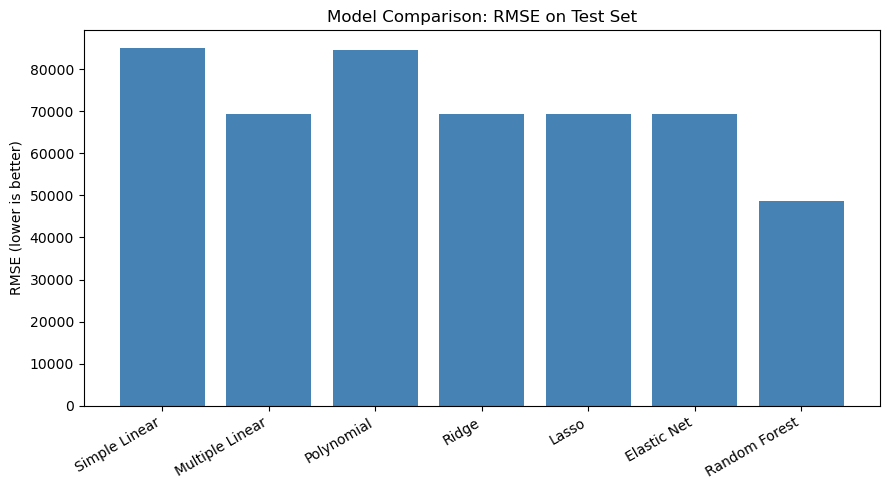

In [55]:
plt.figure(figsize=(9, 5))
plt.bar(comparison["Model"], comparison["RMSE"], color="steelblue")
plt.xticks(rotation=30, ha="right")
plt.ylabel("RMSE (lower is better)")
plt.title("Model Comparison: RMSE on Test Set")
plt.tight_layout()
plt.show()